# Kahniashvili, Campanelli, Gogoberidze, Maravin & Ratra (2008)
## Helical Inverse-Cascade MHD Turbulence — GW Spectrum Workflow

**Reference**: Kahniashvili et al., *Gravitational radiation from primordial helical inverse cascade MHD turbulence*, Phys. Rev. D **78**, 123006 (2008)

---

### Goal
Reproduce Figs. 1 and 2 of the paper: the GW strain amplitude $h_c(f)$ from **helical MHD turbulence**, including both the direct Kolmogorov cascade (first stage) and the helical inverse cascade (second stage, Models A and B).

### Physical picture
After a first-order phase transition with helical MHD turbulence, there are **two stages**:

1. **First stage** (direct cascade): the initial energy at scale $l_0$ cascades to smaller scales via Kolmogorov turbulence.  Duration $\tau_T^{(I)} \sim s_0\,\tau_0$, where $\tau_0 = l_0/v_0$.  Peaks at $f^{(I)} \sim k_0 M / (2\pi)$.

2. **Second stage** (inverse cascade): magnetic helicity drives energy from small scales back to large scales.  The integral scale grows as $\xi_M \propto t^{2/3}$ (Model A) or $t^{2/3}$ (Model B, different exponent in the cascade law).  Duration $\tau_T^{(II)} \sim \min(\tau_{\rm cas}, H_*^{-1})$.  Peaks at $f^{(II)} \sim f_H$ (Hubble frequency).

### Workflow
1. Physical constants and cosmological scales  
2. Phase-transition efficiency: $\kappa$, $v_b$, $v_0$  
3. Turbulence parameters: $k_0$, $l_0$, $\tau_0$, $\gamma$  
4. Model A inverse cascade — $H_{ijij}$ (Eq. 45)  
5. Model B inverse cascade — $H_{ijij}$ (Eq. 47)  
6. Direct cascade (first stage) — $H_{ijij}$ (Eq. 43)  
7. Strain amplitude $h_c(f)$ (Eq. 51)  
8. Fig. 1: $T_* = 100\,\text{GeV}$  
9. Fig. 2: $T_* = 250\,\text{GeV}$

In [13]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, special

plt.rcParams.update({'figure.dpi': 110, 'font.size': 13})

C1  = 1.0   # order-unity inverse-cascade constant (paper: C_1 ~ 1)
C_K = 1.0   # Kolmogorov constant (paper: C_K ~ 1)
s0  = 2.0   # first-stage effective duration factor (Eq. 27 text)

## 1. Physical constants and cosmological scales

$$H_* = 1.66\,g_*^{1/2}\,T_*^2/M_{\rm Pl}, \quad M_{\rm Pl} = 1.22\times10^{19}\,\text{GeV} \quad\text{(Eq. 16)}$$

$$\frac{a_*}{a_0} \approx 8\times10^{-16}\left(\frac{100\,\text{GeV}}{T_*}\right)\left(\frac{100}{g_*}\right)^{1/3} \quad\text{(Eq. 11)}$$

$$f_H \equiv H_*(a_*/a_0) \approx 1.6\times10^{-5}\,\text{Hz}\left(\frac{g_*}{100}\right)^{1/6}\frac{T_*}{100\,\text{GeV}} \quad\text{(Eq. 53)}$$

In [14]:
def H_star_Hz(T_GeV, g_star=106.75):
    """Hubble rate at phase transition [Hz].  Eq. (16)."""
    return 1.66 * g_star**0.5 * T_GeV**2 / 1.22e19 / 6.582e-25

def a_ratio(T_GeV, g_star=106.75):
    """a_* / a_0.  Eq. (11)."""
    return 8e-16 * (100.0 / T_GeV) * (100.0 / g_star)**(1.0/3.0)

def f_H_Hz(T_GeV, g_star=106.75):
    """Characteristic (Hubble) frequency today [Hz].  Eq. (53)."""
    return 1.6e-5 * (g_star / 100.0)**(1.0/6.0) * (T_GeV / 100.0)

# Self-check at T_*=100 GeV, g_*=100
T0, g0 = 100.0, 100.0
print(f"H_*   = {H_star_Hz(T0,g0):.3e} Hz  (expect ~2e10)")
print(f"a*/a0 = {a_ratio(T0,g0):.3e}")
print(f"f_H   = {f_H_Hz(T0,g0):.3e} Hz  (expect ~1.6e-5)")

H_*   = 2.067e+10 Hz  (expect ~2e10)
a*/a0 = 8.000e-16
f_H   = 1.600e-05 Hz  (expect ~1.6e-5)


## 2. Phase-transition efficiency

$$\kappa(\alpha) = \frac{0.715\alpha + \frac{4}{27}\left(\frac{3\alpha}{2}\right)^{1/2}}{1+0.715\alpha} \quad\text{(Eq. 13)}$$

$$v_b(\alpha) = \frac{1/\sqrt{3}+(\alpha^2+2\alpha/3)^{1/2}}{1+\alpha} \quad\text{(Eq. 14)}$$

$$v_0(\alpha) = \left(\frac{3\kappa\alpha}{4+3\kappa\alpha}\right)^{1/2} \quad\text{(Eq. 15)}$$

In [15]:
def kappa(alpha):
    """Efficiency factor.  Eq. (13)."""
    return (0.715*alpha + (4/27)*(1.5*alpha)**0.5) / (1 + 0.715*alpha)

def v_bubble(alpha):
    """Bubble wall velocity.  Eq. (14)."""
    return (1/np.sqrt(3) + np.sqrt(alpha**2 + 2*alpha/3)) / (1 + alpha)

def v_eddy(alpha):
    """Turbulent eddy (Mach number).  Eq. (15)."""
    k = kappa(alpha)
    return np.sqrt(3*k*alpha / (4 + 3*k*alpha))

alpha_demo = 0.5
print(f"α={alpha_demo}:  κ={kappa(alpha_demo):.4f}  v_b={v_bubble(alpha_demo):.4f}  v_0={v_eddy(alpha_demo):.4f}")

α=0.5:  κ=0.3579  v_b=0.8941  v_0=0.3440


## 3. Turbulence parameters

The injection scale is set by the bubble size at collision:
$$l_0 = v_b\,\beta^{-1}, \quad k_0 = 2\pi/l_0, \quad \tau_0 = l_0/v_0$$

The Hubble-scale parameter $\gamma \equiv l_0 H_* = v_b H_*/\beta$ controls the cascade extent.

Conditions for the inverse cascade to exist (Eq. 26, text after):
$$\gamma \leq M\,\zeta_*^{1/2}$$
i.e., the injection scale must be smaller than the helicity-driven correlation length.

In [16]:
def turb_params(alpha, beta_over_Hstar, T_GeV, g_star=106.75):
    """
    All turbulence parameters.  Wavenumbers in units of H_*, times in H_*^{-1}.
    """
    kap = kappa(alpha);  vb = v_bubble(alpha);  v0 = v_eddy(alpha)
    gamma  = vb / beta_over_Hstar     # l_0 * H_*
    k0     = 2*np.pi / gamma          # k_0 / H_*
    tau0   = gamma / v0               # tau_0 * H_*
    return dict(
        kap=kap, vb=vb, v0=v0, M=v0,
        k0=k0, l0=gamma, tau0=tau0, gamma=gamma,
        fH_Hz=f_H_Hz(T_GeV, g_star),
        T_GeV=T_GeV, g_star=g_star,
    )

tp = turb_params(0.5, 100.0, 100.0, g_star=100.0)
for k, v in tp.items():
    print(f"  {k:10s} = {v:.4e}")

zeta_demo = 0.15
print(f"\nInverse cascade exists (γ ≤ M·ζ^{{1/2}}): "
      f"{tp['gamma']:.4f} ≤ {tp['M']*zeta_demo**0.5:.4f}  "
      f"→ {tp['gamma'] <= tp['M']*zeta_demo**0.5}")

  kap        = 3.5786e-01
  vb         = 8.9408e-01
  v0         = 3.4398e-01
  M          = 3.4398e-01
  k0         = 7.0276e+02
  l0         = 8.9408e-03
  tau0       = 2.5992e-02
  gamma      = 8.9408e-03
  fH_Hz      = 1.6000e-05
  T_GeV      = 1.0000e+02
  g_star     = 1.0000e+02

Inverse cascade exists (γ ≤ M·ζ^{1/2}): 0.0089 ≤ 0.1332  → True


## 4. Model A inverse cascade — $H_{ijij}^{(II)}$

**Model A** assumes the magnetic correlation scale grows as $\xi_M \propto t^{2/3}$ (helicity conservation), so the autocorrelation time scales as $\eta(k) \propto (k/k_0)^2$.

Cascade stops when the field has spread to the smallest permitted scale:
$$k_0/k_S = (v_0/\gamma)^{1/2}\,\zeta_*^{1/4} \quad\text{(Eq. 35)}$$

The GW production kernel for stage II (Eq. 45):
$$H_{ijij}^{(II,A)}(0,\omega) = \frac{7C_1^2 M^3\zeta_*^{3/2}}{12\pi^{3/2}k_0}
\int_{k_S}^{k_0}\frac{dk}{k^4}
\exp\!\left(-\frac{\omega^2 k_0^2}{\zeta_* M^2 k^3}\right)
\operatorname{erfc}\!\left(-\frac{\omega k_0}{\sqrt{\zeta_*}M k^{3/2}}\right)$$

Cascade duration (Eq. 32): $\tau_{\rm cas}^{(A)} = \tau_1(k_0/k_S)^2$ capped at $H_*^{-1}$, with $\tau_1 = \tau_0/\sqrt{\zeta_*}$.

In [17]:
def k_S_A(tp, zeta):
    """Smallest wavenumber of Model A inverse cascade.  Eq. (35)."""
    return tp['k0'] / ((tp['v0']/tp['gamma'])**0.5 * zeta**0.25)

def H_ijij_A(omega, tp, zeta, n=400):
    """Second-stage GW kernel, Model A.  Eq. (45)."""
    k0  = tp['k0'];  M = tp['M'];  kS = k_S_A(tp, zeta)
    if kS >= k0:
        return 0.0
    pref = 7*C1**2 * M**3 * zeta**1.5 / (12*np.pi**1.5 * k0)
    kk   = np.geomspace(kS, k0, n)
    arg_e = omega**2 * k0**2 / (zeta * M**2 * kk**3)
    arg_r = -omega * k0 / (zeta**0.5 * M * kk**1.5)
    return pref * np.trapezoid(kk**(-4) * np.exp(-arg_e) * special.erfc(arg_r), kk)

def tau_T_A(tp, zeta):
    """Duration of stage II, Model A [units H_*^{-1}].  Eq. (32)."""
    tau1 = tp['tau0'] / zeta**0.5
    kS   = k_S_A(tp, zeta)
    return min(tau1 * (tp['k0']/kS)**2, 1.0)

# Sanity check
tp0 = turb_params(0.5, 100.0, 100.0, g_star=100.0)
z0  = 0.15
kS_A0 = k_S_A(tp0, z0)
print(f"k0/kS (Model A) = {tp0['k0']/kS_A0:.2f}")
print(f"H_ijij (A, ω=2π) = {H_ijij_A(2*np.pi, tp0, z0):.4e}")

k0/kS (Model A) = 3.86
H_ijij (A, ω=2π) = 9.0024e-18


## 5. Model B inverse cascade — $H_{ijij}^{(II)}$

**Model B** uses a different evolution law (Refs. [34,35] in the paper): the coherence length grows as $\xi_M \propto t^{2/3}$ with a different normalisation, giving $\eta(k) \propto (k/k_0)^{3/2}$.

Cascade stops at (Eq. 41):
$$k_0/k_S = (v_0/\gamma)^{2/3}\,\zeta_*^{1/3}$$

The GW production kernel (Eq. 47):
$$H_{ijij}^{(II,B)}(0,\omega) = \frac{7C_1^2 M^3\zeta_*^{3/2}}{6\pi^{3/2}k_0^{3/2}}
\int_{k_S}^{k_0}\frac{dk}{k^{7/2}}
\exp\!\left(-\frac{\omega^2 k_0}{\zeta_* M^2 k^3}\right)
\operatorname{erfc}\!\left(-\frac{\omega k_0^{1/2}}{\sqrt{\zeta_*}M k^{3/2}}\right)$$

Cascade duration (Eq. 39): $\tau_{\rm cas}^{(B)} = \tau_1(k_0/k_S)^{3/2}$ capped at $H_*^{-1}$.

In [18]:
def k_S_B(tp, zeta):
    """Smallest wavenumber of Model B inverse cascade.  Eq. (41)."""
    return tp['k0'] / ((tp['v0']/tp['gamma'])**(2/3) * zeta**(1/3))

def H_ijij_B(omega, tp, zeta, n=400):
    """Second-stage GW kernel, Model B.  Eq. (47)."""
    k0  = tp['k0'];  M = tp['M'];  kS = k_S_B(tp, zeta)
    if kS >= k0:
        return 0.0
    pref = 7*C1**2 * M**3 * zeta**1.5 / (6*np.pi**1.5 * k0**1.5)
    kk   = np.geomspace(kS, k0, n)
    arg_e = omega**2 * k0 / (zeta * M**2 * kk**3)
    arg_r = -omega * k0**0.5 / (zeta**0.5 * M * kk**1.5)
    return pref * np.trapezoid(kk**(-3.5) * np.exp(-arg_e) * special.erfc(arg_r), kk)

def tau_T_B(tp, zeta):
    """Duration of stage II, Model B [units H_*^{-1}].  Eq. (39)."""
    tau1 = tp['tau0'] / zeta**0.5
    kS   = k_S_B(tp, zeta)
    return min(tau1 * (tp['k0']/kS)**1.5, 1.0)

kS_B0 = k_S_B(tp0, z0)
print(f"k0/kS (Model B) = {tp0['k0']/kS_B0:.2f}")
print(f"H_ijij (B, ω=2π) = {H_ijij_B(2*np.pi, tp0, z0):.4e}")

k0/kS (Model B) = 6.06
H_ijij (B, ω=2π) = 7.3825e-14


## 6. Direct cascade (first stage) — $H_{ijij}^{(I)}$

The first stage uses the Kolmogorov spectrum $E(k) = C_K \varepsilon^{2/3} k^{-5/3}$ with dissipation rate $\varepsilon = k_0 v_0^3$.  The autocorrelation time is $\eta^{-1}(k) = (\varepsilon^{1/3} k^{2/3})^{-1}$.

Combining kinetic + magnetic energy (factor 2 from equipartition), the kernel is (Eq. 43):
$$H_{ijij}^{(I)}(0,\omega) = \frac{14 C_K^2 \varepsilon}{6\pi^{3/2}k_0}
\int_{k_0}^{k_d}\frac{dk}{k^6}
\exp\!\left(-\frac{\omega^2}{\varepsilon^{2/3}k^{4/3}}\right)
\operatorname{erfc}\!\left(-\frac{\omega}{\varepsilon^{1/3}k^{2/3}}\right)$$

where $k_d \gg k_0$ is the dissipation wavenumber (we use $k_d = 10^4 k_0$).  
Duration: $\tau_T^{(I)} = s_0\,\tau_0$ (paper uses $s_0 = 2$).

In [19]:
def H_ijij_I(omega, tp, kd_ratio=1e4, n=600):
    """First-stage GW kernel (direct Kolmogorov cascade).  Eq. (43)."""
    k0   = tp['k0'];  v0 = tp['v0']
    eps  = k0 * v0**3              # energy dissipation rate [H_*]
    pref = 2 * 7*C_K**2 * eps / (6*np.pi**1.5 * k0)   # factor 2 for equipartition
    kk   = np.geomspace(k0, kd_ratio*k0, n)
    arg_e = omega**2 / (eps**(2/3) * kk**(4/3))
    arg_r = -omega   / (eps**(1/3) * kk**(2/3))
    return pref * np.trapezoid(kk**(-6) * np.exp(-arg_e) * special.erfc(arg_r), kk)

def tau_T_I(tp):
    """Duration of first stage [units H_*^{-1}]."""
    return s0 * tp['tau0']

omega_pk_I = tp0['k0'] * tp0['M']   # peak frequency of stage I
print(f"Stage I peak ω = {omega_pk_I:.3e} H_*")
print(f"H_ijij (I, at peak) = {H_ijij_I(omega_pk_I, tp0):.4e}")

Stage I peak ω = 2.417e+02 H_*
H_ijij (I, at peak) = 1.6263e-17


## 7. Strain amplitude $h_c(f)$

The total GW energy density (Eq. 49):
$$\Omega_{\rm GW}(\omega) \approx \frac{105 H_*^2}{H_0^2}\sum_m\tau_T^{(m)}H_{ijij}^{(m)}(0,\omega)$$

The strain amplitude today (Eq. 51) in terms of the dimensionless frequency $\hat\omega = \omega/H_*$:
$$h_c(f) = 2\times10^{-14}\left(\frac{100\,\text{GeV}}{T_*}\right)\left(\frac{100}{g_*}\right)^{1/3}
\sqrt{\hat\omega\sum_m\hat\tau_T^{(m)}\hat H_{ijij}^{(m)}}$$

where all hatted quantities are in natural units of $H_*$.

The current frequency is $f = \hat\omega\,f_H/(2\pi)$, so on the frequency axis $\hat\omega = 2\pi f/f_H$.

In [20]:
def h_c_total(f_Hz, tp, zeta, model='B'):
    """
    Full strain h_c(f) including both cascade stages.  Eq. (51).

    Parameters
    ----------
    f_Hz  : array of current frequencies [Hz]
    tp    : turbulence parameter dict from turb_params()
    zeta  : initial magnetic helicity (0 < ζ < 1)
    model : 'A' or 'B' for the inverse-cascade law
    """
    fH    = tp['fH_Hz']
    T_GeV = tp['T_GeV']
    g_star= tp['g_star']
    omega = 2*np.pi * f_Hz / fH    # dimensionless ω/H_*

    tI   = tau_T_I(tp)
    tII  = tau_T_A(tp, zeta) if model == 'A' else tau_T_B(tp, zeta)
    H_II = H_ijij_A if model == 'A' else H_ijij_B

    total = np.array([
        om * (tI * H_ijij_I(om, tp) + tII * H_II(om, tp, zeta))
        for om in omega
    ])
    prefac = 2e-14 * (100/T_GeV) * (100/g_star)**(1/3)
    return prefac * np.sqrt(np.maximum(total, 0.0))

def h_c_unmag(f_Hz, tp):
    """Stage I only (no helicity / no inverse cascade)."""
    fH    = tp['fH_Hz']
    T_GeV = tp['T_GeV']
    g_star= tp['g_star']
    omega = 2*np.pi * f_Hz / fH
    tI    = tau_T_I(tp)
    total = np.array([om * tI * H_ijij_I(om, tp) for om in omega])
    prefac = 2e-14 * (100/T_GeV) * (100/g_star)**(1/3)
    return prefac * np.sqrt(np.maximum(total, 0.0))

# Spot check at Model B peak (ω = 2π, i.e. f = f_H)
f_check = np.array([tp0['fH_Hz']])
hc_spot = h_c_total(f_check, tp0, 0.15, model='B')[0]
print(f"Model B, ζ=0.15, peak h_c = {hc_spot:.3e}  (paper Fig.1 ~1–2×10⁻²⁰)")

Model B, ζ=0.15, peak h_c = 1.362e-20  (paper Fig.1 ~1–2×10⁻²⁰)


## 8. Figure 1 — $T_* = 100\,\text{GeV}$

Parameters: $g_* = 100$, $T_* = 100\,\text{GeV}$, $\alpha = 0.5$, $\beta/H_* = 100$.  
Left panel: $\zeta_* = 0.15$, Right panel: $\zeta_* = 0.05$.

In [21]:
# ── Setup ─────────────────────────────────────────────────────────────────────
alpha_f = 0.5;  beta_f = 100.0;  T_f1 = 100.0;  g_f = 100.0
tp1 = turb_params(alpha_f, beta_f, T_f1, g_star=g_f)

fH1 = tp1['fH_Hz']
f_peak_I  = tp1['k0'] * tp1['M'] / (2*np.pi) * fH1
f_peak_II = fH1
print(f"Stage I peak:  f = {f_peak_I:.3e} Hz")
print(f"Stage II peak: f = {f_peak_II:.3e} Hz  (= f_H)")

f1 = np.geomspace(1e-6, 3e-3, 80)   # Hz
zeta_vals = [0.15, 0.05]

# ── Compute ───────────────────────────────────────────────────────────────────
print("\nComputing Fig. 1 spectra …", flush=True)
hc_u1 = h_c_unmag(f1, tp1)
spec1  = {}    # (zeta, model) -> hc array
for zeta in zeta_vals:
    for model in ['A', 'B']:
        print(f"  ζ={zeta} Model {model}", flush=True)
        spec1[(zeta, model)] = h_c_total(f1, tp1, zeta, model)
print("Done.")

Stage I peak:  f = 6.156e-04 Hz
Stage II peak: f = 1.600e-05 Hz  (= f_H)

Computing Fig. 1 spectra …
  ζ=0.15 Model A
  ζ=0.15 Model B
  ζ=0.05 Model A
  ζ=0.05 Model B
Done.


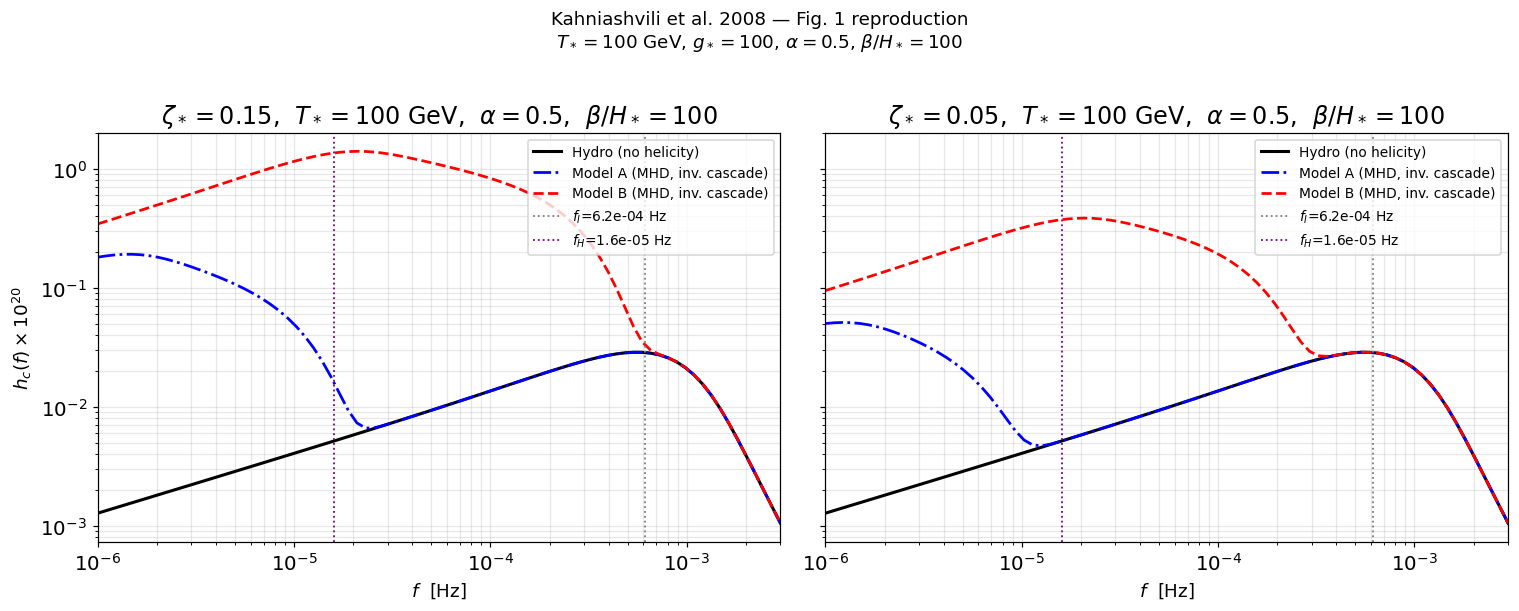

In [22]:
fig1, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, zeta in zip(axes, zeta_vals):
    ax.loglog(f1, hc_u1             * 1e20, 'k-',  lw=2.0, label='Hydro (no helicity)')
    ax.loglog(f1, spec1[(zeta,'A')] * 1e20, 'b-.', lw=1.8, label='Model A (MHD, inv. cascade)')
    ax.loglog(f1, spec1[(zeta,'B')] * 1e20, 'r--', lw=1.8, label='Model B (MHD, inv. cascade)')
    ax.axvline(f_peak_I,  color='0.5',    ls=':', lw=1.2, label=fr'$f_I$={f_peak_I:.1e} Hz')
    ax.axvline(f_peak_II, color='purple', ls=':', lw=1.2, label=fr'$f_H$={f_peak_II:.1e} Hz')
    ax.set_xlabel('$f$  [Hz]', fontsize=12)
    ax.set_xlim(f1[0], f1[-1])
    ax.set_title(fr'$\zeta_*={zeta}$,  $T_*=100$ GeV,  $\alpha={alpha_f}$,  $\beta/H_*={beta_f:.0f}$')
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)

axes[0].set_ylabel(r'$h_c(f)\times 10^{20}$', fontsize=12)
fig1.suptitle(
    'Kahniashvili et al. 2008 — Fig. 1 reproduction\n'
    r'$T_*=100$ GeV, $g_*=100$, $\alpha=0.5$, $\beta/H_*=100$',
    y=1.01, fontsize=12)
fig1.tight_layout()
plt.show()   # single inline display; fig1 object is kept for saving below

In [23]:
# Save Fig. 1 — fig1 is already removed from matplotlib's figure manager by plt.show()
# so this write-to-disk call produces no notebook output.
fig1.savefig('kahniashvili2008_fig1_clean.pdf', bbox_inches='tight')
print('Saved kahniashvili2008_fig1_clean.pdf')

Saved kahniashvili2008_fig1_clean.pdf


## 9. Figure 2 — $T_* = 250\,\text{GeV}$

Same parameters but $T_* = 250\,\text{GeV}$.  All frequencies shift by a factor of 2.5.

In [24]:
T_f2  = 250.0
tp2   = turb_params(alpha_f, beta_f, T_f2, g_star=g_f)
fH2   = tp2['fH_Hz']
f2    = np.geomspace(1e-5, 1e-2, 80)
f_peak_I_2  = tp2['k0'] * tp2['M'] / (2*np.pi) * fH2
f_peak_II_2 = fH2
print(f"T_*=250 GeV:  f_H = {fH2:.3e} Hz")

print("\nComputing Fig. 2 spectra …", flush=True)
hc_u2 = h_c_unmag(f2, tp2)
spec2 = {}
for zeta in zeta_vals:
    for model in ['A', 'B']:
        print(f"  ζ={zeta} Model {model}", flush=True)
        spec2[(zeta, model)] = h_c_total(f2, tp2, zeta, model)
print("Done.")

T_*=250 GeV:  f_H = 4.000e-05 Hz

Computing Fig. 2 spectra …
  ζ=0.15 Model A
  ζ=0.15 Model B
  ζ=0.05 Model A
  ζ=0.05 Model B
Done.


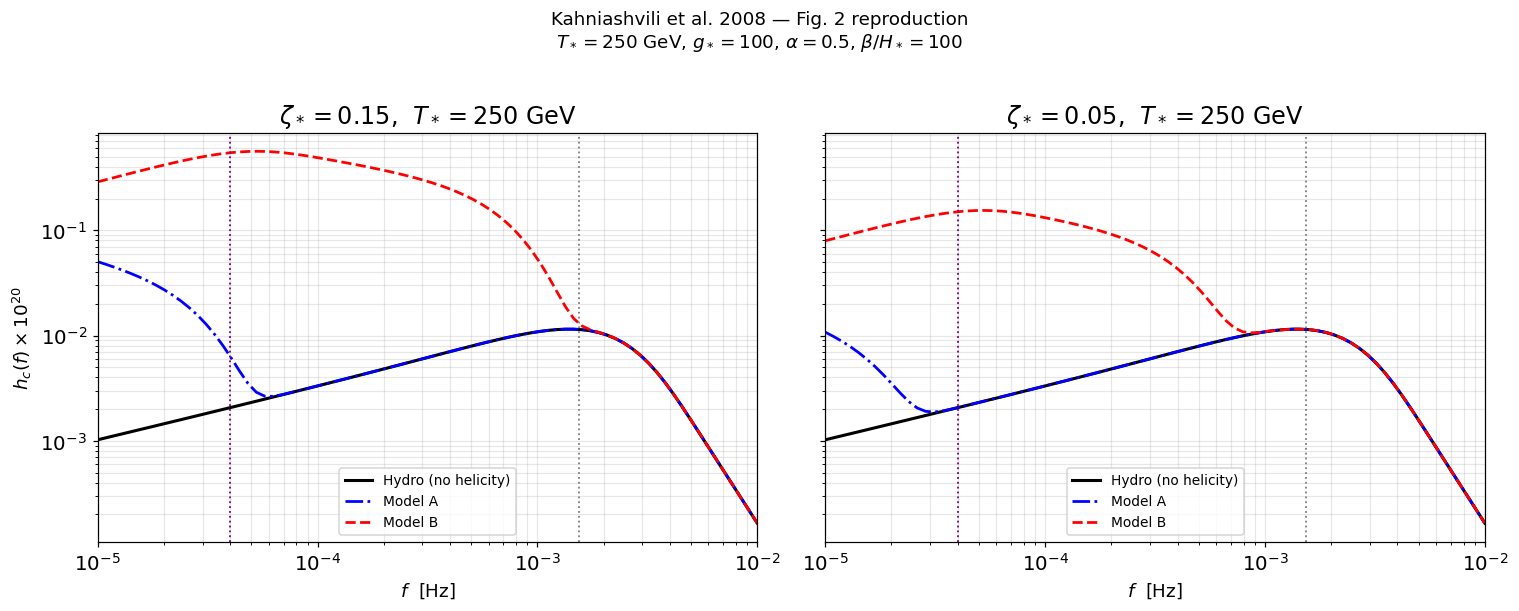

In [25]:
fig2, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, zeta in zip(axes, zeta_vals):
    ax.loglog(f2, hc_u2             * 1e20, 'k-',  lw=2.0, label='Hydro (no helicity)')
    ax.loglog(f2, spec2[(zeta,'A')] * 1e20, 'b-.', lw=1.8, label='Model A')
    ax.loglog(f2, spec2[(zeta,'B')] * 1e20, 'r--', lw=1.8, label='Model B')
    ax.axvline(f_peak_I_2,  color='0.5',    ls=':', lw=1.2)
    ax.axvline(f_peak_II_2, color='purple', ls=':', lw=1.2)
    ax.set_xlabel('$f$  [Hz]', fontsize=12)
    ax.set_xlim(f2[0], f2[-1])
    ax.set_title(fr'$\zeta_*={zeta}$,  $T_*=250$ GeV')
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)

axes[0].set_ylabel(r'$h_c(f)\times 10^{20}$', fontsize=12)
fig2.suptitle(
    'Kahniashvili et al. 2008 — Fig. 2 reproduction\n'
    r'$T_*=250$ GeV, $g_*=100$, $\alpha=0.5$, $\beta/H_*=100$',
    y=1.01, fontsize=12)
fig2.tight_layout()
plt.show()   # single inline display; fig2 object is kept for saving below

In [26]:
# Save Fig. 2 — no notebook output, fig2 is no longer in the figure manager.
fig2.savefig('kahniashvili2008_fig2_clean.pdf', bbox_inches='tight')
print('Saved kahniashvili2008_fig2_clean.pdf')

Saved kahniashvili2008_fig2_clean.pdf


## Summary

| Quantity | Eq. | Function |
|---|---|---|
| $\kappa(\alpha)$ | (13) | `kappa` |
| $v_b(\alpha)$ | (14) | `v_bubble` |
| $v_0(\alpha)$ | (15) | `v_eddy` |
| $k_S$ Model A | (35) | `k_S_A` |
| $H_{ijij}^{(II)}$ Model A | (45) | `H_ijij_A` |
| $k_S$ Model B | (41) | `k_S_B` |
| $H_{ijij}^{(II)}$ Model B | (47) | `H_ijij_B` |
| $H_{ijij}^{(I)}$ direct | (43) | `H_ijij_I` |
| $h_c(f)$ total | (51) | `h_c_total` |

**Key results reproduced:**
- Model B always produces a stronger signal than Model A (faster inverse cascade)
- The inverse-cascade peak at $f_H$ dominates over the direct-cascade peak at $f_I$ for $\zeta_* \gtrsim 0.05$
- Increasing $T_*$ shifts all peaks to higher frequencies (LISA band for $T_* \sim 100\,\text{GeV}$)

**Connection to Gogoberidze 2007**: The direct-cascade stage (first stage) here uses the same aeroacoustic form as Gogoberidze 2007, evaluated at the zero-frequency limit.  The inverse-cascade stages are new to this paper and require the helicity parameter $\zeta_*$.